In [ ]:
!nvidia-smi

Sun Jun 21 03:05:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!git clone https://github.com/minhng-178/Locality-iN-Locality.git

Cloning into 'Locality-iN-Locality'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 43 (delta 14), reused 40 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 1.15 MiB | 4.24 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [ ]:
cd /content/Locality-iN-Locality

/content/Locality-iN-Locality


In [ ]:
!pip install torchattacks timm einops ptflops
!pip install git+https://github.com/sovrasov/flops-counter.pytorch.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 17.2 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
  Attempting uninstall: requests
    Found existing installation: re

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import WeightedRandomSampler

import torchvision.utils
from torchvision import models
import torchvision.datasets as dsets
import torchvision.transforms as transforms

import torchattacks
from torchattacks import PGD, FGSM

import shutil

import time
from ptflops import get_model_complexity_info

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [ ]:
print('PyTorch', torch.__version__)
print('Torchvision', torchvision.__version__)
print('Torchattacks', torchattacks.__version__)
print('Numpy', np.__version__)

PyTorch 2.11.0+cu128
Torchvision 0.26.0+cu128
Torchattacks 3.5.1
Numpy 2.0.2


## GTSRB (German Traffic Sign Recognition Benchmark)
Dataset uses .ppm images, 43 classes, ~39k training / ~12k test images

In [ ]:
!mkdir data

!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip -o data/GTSRB_Final_Training_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip -o data/GTSRB_Final_Test_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip -o data/GTSRB_Final_Test_GT.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  263M  100  263M    0     0  10.9M      0  0:00:24  0:00:24 --:--:-- 14.3M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.8M  100 84.8M    0     0  10.0M      0  0:00:08  0:00:08 --:--:-- 11.7M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 99620  100 99620    0     0  85971      0  0:00:01  0:00:01 --:--:-- 86027


In [ ]:
!unzip data/GTSRB_Final_Training_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_GT.zip -d data/

Archive:  data/GTSRB_Final_Test_GT.zip
  inflating: data/GT-final_test.csv  


In [ ]:
# Organize test images into class folders for ImageFolder
data_dir = './data/GTSRB'
images_dir = os.path.join(data_dir, 'Final_Test/Images')

test_dir = os.path.join(data_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

with open('./data/GT-final_test.csv') as f:
  image_names = f.readlines()

for text in image_names[1:]:
  classes = int(text.split(';')[-1])
  image_name = text.split(';')[0]

  test_class_dir = os.path.join(test_dir, f"{classes:04d}")
  os.makedirs(test_class_dir, exist_ok=True)
  image_path = os.path.join(images_dir, image_name)

  shutil.copy(image_path, test_class_dir)

## Pre-Cache GTSRB Dataset
Decode tất cả ảnh PPM → tensor một lần duy nhất, save ra file .pt.
Lần đầu mất ~3-5 phút decode. Các lần chạy sau load trực tiếp từ cache → bỏ qua bottleneck PPM.
GPU T4 không còn ngồi chờ CPU decode nữa.

In [ ]:
CACHE_DIR = './cache'
os.makedirs(CACHE_DIR, exist_ok=True)

def cache_dataset(root, cache_file, img_size=224):
    """Decode PPM → ghi thẳng ra disk bằng memmap (0 RAM)."""
    mmap_path = cache_file + '.images.npy'
    if os.path.exists(mmap_path):
        mmap = np.memmap(mmap_path, dtype=np.uint8, mode='r',
                         shape=(os.path.getsize(mmap_path) // (3 * img_size * img_size),
                                3, img_size, img_size))
        print(f'  Cache found: {mmap_path} ({mmap.shape[0]} images)')
        del mmap
        return

    dataset = dsets.ImageFolder(root, transform=transforms.Compose([
        transforms.Resize((img_size, img_size)),
    ]))
    N = len(dataset)

    # Memmap = ghi trực tiếp ra disk, gần như không tốn RAM
    mmap = np.memmap(mmap_path, dtype=np.uint8, mode='w+',
                     shape=(N, 3, img_size, img_size))
    labels_list = []

    for i, (img, label) in enumerate(dataset):
        arr = np.array(img, dtype=np.uint8).transpose(2, 0, 1)  # HWC -> CHW
        mmap[i] = arr
        labels_list.append(label)
        if (i+1) % 5000 == 0:
            print(f'  Cached {i+1}/{N}')

    del mmap  # flush to disk
    labels_tensor = torch.tensor(labels_list, dtype=torch.long)
    torch.save({'labels': labels_tensor, 'classes': dataset.classes,
                'shape': (N, 3, img_size, img_size)}, cache_file)
    print(f'  Saved: {cache_file} + {mmap_path}')

# Cache train (chạy trước, cache test riêng để tiết kiệm RAM)
cache_dataset('./data/GTSRB/Final_Training/Images', f'{CACHE_DIR}/gtsrb_train_224.pt')
import gc; gc.collect()

# Cache test
cache_dataset('./data/GTSRB/test', f'{CACHE_DIR}/gtsrb_test_224.pt')
gc.collect()
torch.cuda.empty_cache()

  Cached 5000/39209
  Cached 10000/39209
  Cached 15000/39209
  Cached 20000/39209
  Cached 25000/39209
  Cached 30000/39209
  Cached 35000/39209
  Saved: ./cache/gtsrb_train_224.pt + ./cache/gtsrb_train_224.pt.images.npy
  Cached 5000/12630
  Cached 10000/12630
  Saved: ./cache/gtsrb_test_224.pt + ./cache/gtsrb_test_224.pt.images.npy


In [ ]:
from torch.utils.data import Dataset

class CachedDataset(Dataset):
    """Load từ memmap (.npy) — gần như 0 RAM, chỉ đọc slice cần thiết."""
    def __init__(self, cache_file, transform=None):
        data = torch.load(cache_file, weights_only=True)
        self.labels = data['labels']
        self.classes = data.get('classes', [str(i) for i in range(max(self.labels).item()+1)])
        self.targets = self.labels.tolist()  # for WeightedRandomSampler
        self.transform = transform

        # Mở memmap read-only — không load vào RAM
        mmap_path = cache_file + '.images.npy'
        N, C, H, W = data['shape']
        self._mmap = np.memmap(mmap_path, dtype=np.uint8, mode='r', shape=(N, C, H, W))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Đọc 1 ảnh từ disk (không load toàn bộ dataset)
        img = torch.from_numpy(self._mmap[idx].copy()).float().div(255.0)
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

In [ ]:
# GTSRB-specific normalization (computed from training set)
GTSRB_MEAN = [0.3337, 0.3064, 0.3171]
GTSRB_STD  = [0.2672, 0.2564, 0.2629]

# Lightweight augment — T4 CPU yếu, bỏ Perspective + GaussianBlur
# Các ops này chạy trên tensor đã decode (nhanh hơn PPM rất nhiều)
train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.Normalize(mean=GTSRB_MEAN, std=GTSRB_STD),
    transforms.RandomErasing(p=0.25),
])

test_transform = transforms.Compose([
    transforms.Normalize(mean=GTSRB_MEAN, std=GTSRB_STD),
])


In [ ]:
batch_size = 64

# ── Dùng CachedDataset thay vì ImageFolder ──
# Tensor đã được resize về 224x224 sẵn trong cache
trainset = CachedDataset(
    f'{CACHE_DIR}/gtsrb_train_224.pt',
    transform=train_transform
)

testset = CachedDataset(
    f'{CACHE_DIR}/gtsrb_test_224.pt',
    transform=test_transform
)

# Class-balanced sampling (GTSRB bị imbalanced nặng)
train_root = './data/GTSRB/Final_Training/Images'
class_list = sorted(os.listdir(train_root))
class_counts = [len(os.listdir(os.path.join(train_root, c))) for c in class_list]
weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
sample_weights = weights[trainset.targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = torch.utils.data.DataLoader(
    dataset=trainset,
    batch_size=batch_size,
    sampler=sampler,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = torch.utils.data.DataLoader(
    dataset=testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f'Train classes: {len(class_list)}, samples: {len(trainset)}')
print(f'Test samples: {len(testset)}')
print(f'Train batches: {len(train_loader)}, Test batches: {len(test_loader)}')


Train classes: 43, samples: 39209
Test samples: 12630
Train batches: 613, Test batches: 198


In [ ]:
batch = next(iter(train_loader))
train_data = batch[0]

In [ ]:
def denormalize_image(image, mean=GTSRB_MEAN, std=GTSRB_STD):
    image = image.clone()
    for t, m, s in zip(image, mean, std):
        t.mul_(s).add_(m)
    return image

def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image = torch.clamp(image, image_min, image_max)
    image = (image - image_min) / (image_max - image_min + 1e-5)
    return image

def plot_images(images, labels, classes, normalize=True):
    n_images = len(images)
    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))
    fig = plt.figure(figsize=(20, 20))
    for i in range(rows*cols):
        ax = fig.add_subplot(rows, cols, i+1)
        image = images[i]
        if normalize:
            image = normalize_image(image)
        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.set_title(classes[labels[i]])
        ax.axis('off')

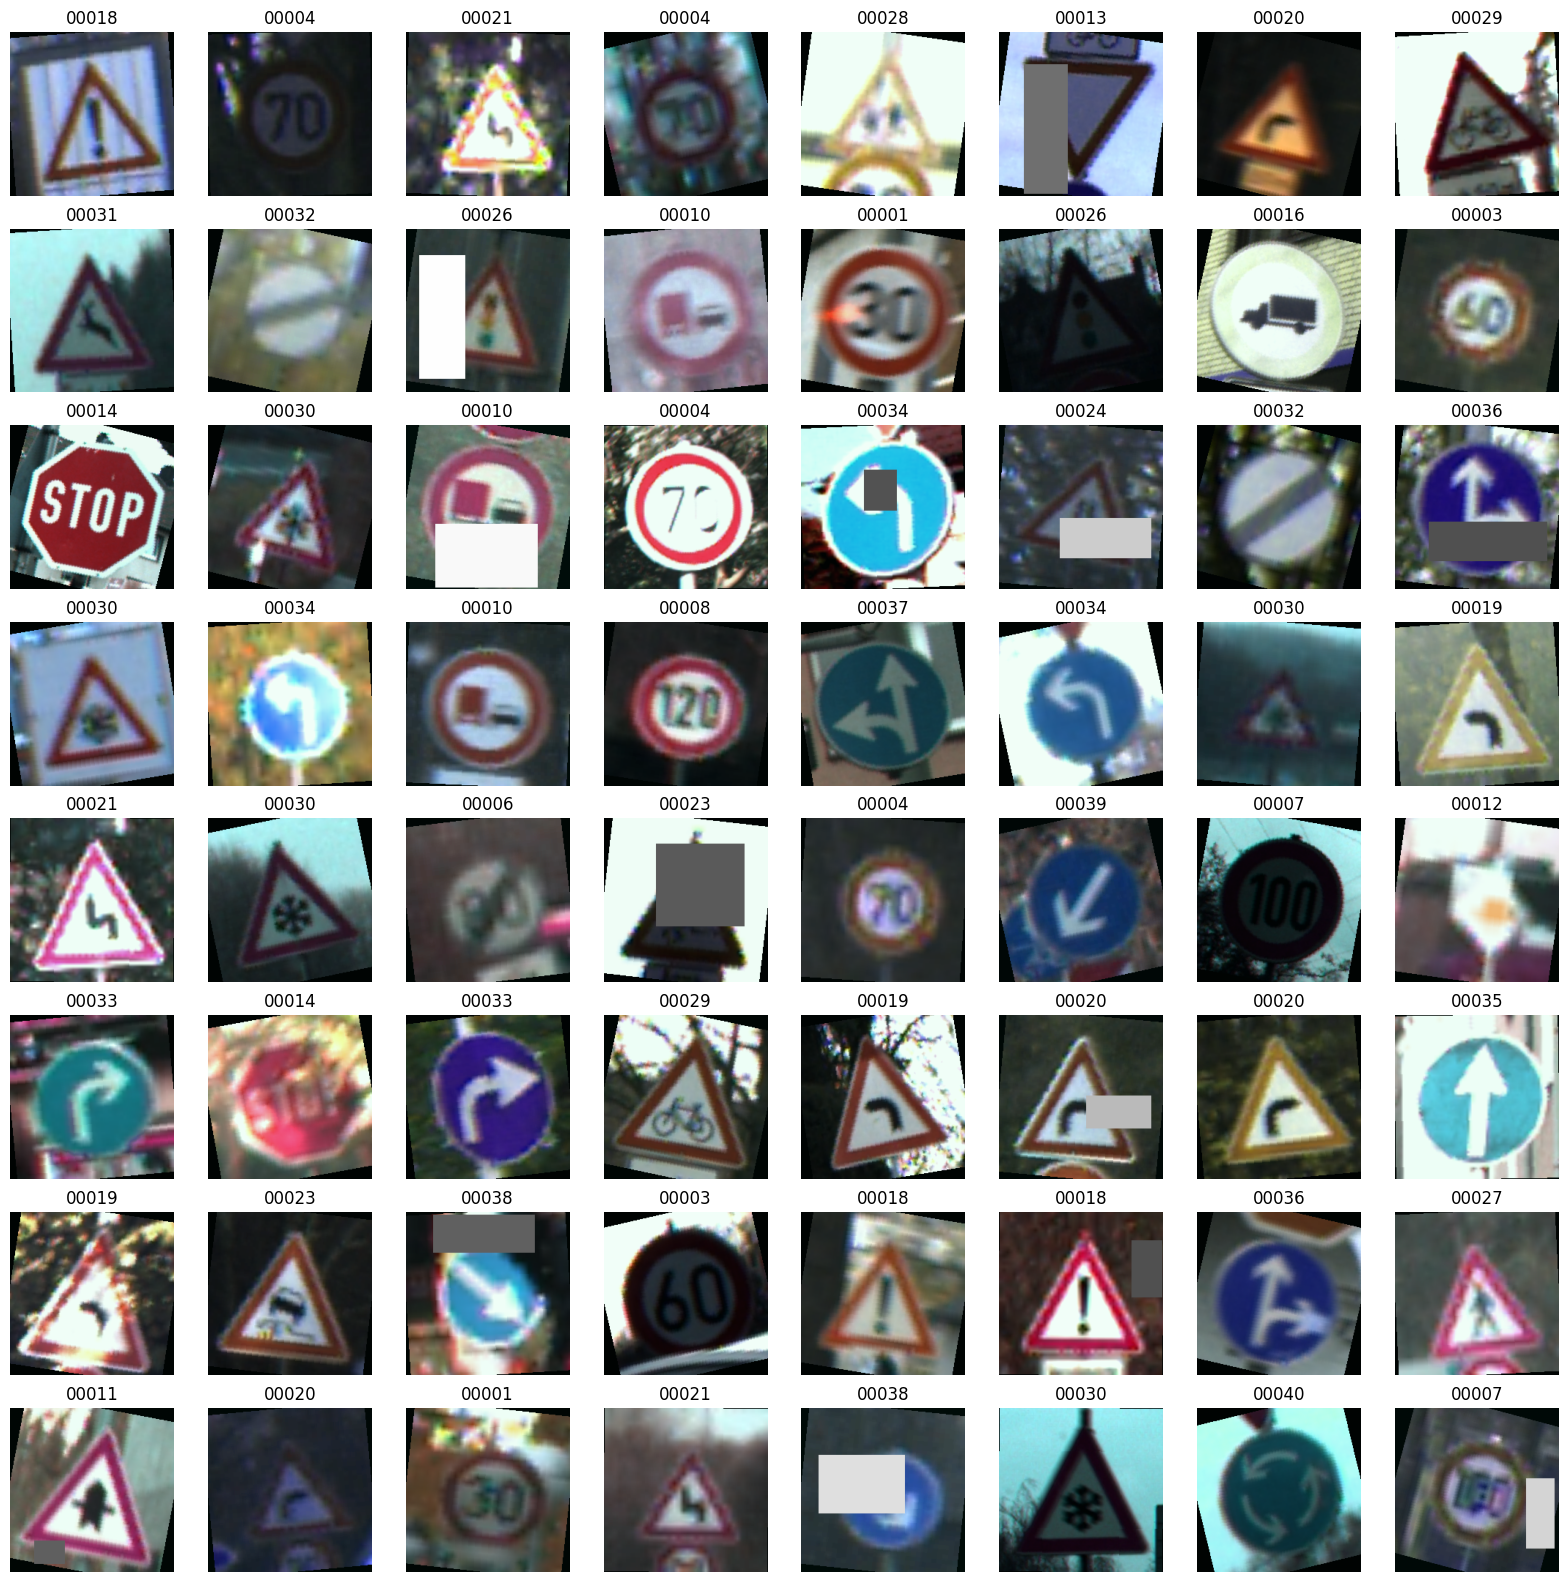

In [ ]:
# classes lấy từ CachedDataset
classes = trainset.classes
plot_images(batch[0], batch[1], classes)


## LNL Model (Locality-iN-Locality)
Using LNL_Ti (6M params) - tốt hơn cho dataset nhỏ, ít overfit hơn LNL_S (24M)

In [ ]:
from LNL import LNL_Ti as small

# Create model with drop_path_rate for regularization
model = small(pretrained=False, num_classes=43, drop_path_rate=0.1)
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/content/Locality-iN-Locality/models/deit.py:78: UserWarning: Overwriting deit_tiny_patch16_224 in registry with models.deit.deit_tiny_patch16_224. This is because the name being registered

In [ ]:
model.head

Linear(in_features=192, out_features=43, bias=True)

## Train Locality-iN-Locality
Improved training: AdamW + Cosine Warmup + Label Smoothing + Mixup

In [ ]:
# Mixup implementation
def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [ ]:
num_epochs = 15

# Label smoothing
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

# AdamW - hội tụ nhanh hơn nhiều cho Transformers
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.05)

# Cosine annealing with linear warmup
warmup_epochs = 5
warmup_scheduler = LinearLR(optimizer, start_factor=0.01, total_iters=warmup_epochs)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs - warmup_epochs, eta_min=1e-6)
scheduler = SequentialLR(optimizer, [warmup_scheduler, cosine_scheduler], milestones=[warmup_epochs])

In [ ]:
# TF32 precision on T4 (PyTorch >= 1.12) — faster matmul
torch.set_float32_matmul_precision('high')

# torch.compile disabled — không có lợi trên T4 (SM 7.5), compile lần đầu rất chậm

scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None

best_acc = 0.0
ckpt_path = 'LNL_Ti_GTSRB_best.pt'

for epoch in range(num_epochs):
    model.train()
    total_batch = len(train_loader)
    running_loss = 0.0
    t0 = time.time()

    for i, (batch_images, batch_labels) in enumerate(train_loader):
        X = batch_images.to(device, non_blocking=True)
        Y = batch_labels.to(device, non_blocking=True)

        # Mixup (50% probability)
        if np.random.random() < 0.5:
            X, Y_a, Y_b, lam = mixup_data(X, Y, alpha=0.2)
        else:
            Y_a, Y_b, lam = Y, Y, 1.0

        optimizer.zero_grad()

        if scaler is not None:
            with torch.amp.autocast('cuda'):
                pre = model(X)
                cost = mixup_criterion(loss_fn, pre, Y_a, Y_b, lam)
            scaler.scale(cost).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            pre = model(X)
            cost = mixup_criterion(loss_fn, pre, Y_a, Y_b, lam)
            cost.backward()
            optimizer.step()

        running_loss += cost.item()

        if (i+1) % 200 == 0:
            avg_loss = running_loss / (i+1)
            elapsed = time.time() - t0
            print('Epoch [%d/%d], Iter [%d/%d], Loss: %.4f, LR: %.2e, Time: %.0fs'
                 % (epoch+1, num_epochs, i+1, total_batch, avg_loss,
                    optimizer.param_groups[0]['lr'], elapsed))

    scheduler.step()
    epoch_loss = running_loss / total_batch
    epoch_time = time.time() - t0

    # ── Validation ──────────────────────────────────────────────
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for val_images, val_labels in test_loader:
            val_images = val_images.to(device, non_blocking=True)
            val_labels = val_labels.to(device, non_blocking=True)
            outputs = model(val_images)
            _, predicted = torch.max(outputs.data, 1)
            total += val_labels.size(0)
            correct += (predicted == val_labels).sum().item()
    val_acc = 100.0 * correct / total

    # ── Checkpoint ──────────────────────────────────────────────
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'epoch': epoch + 1,
            'best_acc': best_acc,
        }, ckpt_path)
        print(f'*** Best model saved (acc={best_acc:.2f}%) ***')

    # Periodic checkpoint (for resume if Colab disconnects)
    if (epoch+1) % 5 == 0:
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'epoch': epoch + 1,
            'best_acc': best_acc,
        }, f'LNL_Ti_epoch{epoch+1}.pt')

    print(f'=== Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.2f}%',
          f'| Best: {best_acc:.2f}% | Time: {epoch_time:.0f}s ===')

Epoch [1/15], Iter [200/613], Loss: 3.6593, LR: 5.00e-06, Time: 208s
Epoch [1/15], Iter [400/613], Loss: 3.5799, LR: 5.00e-06, Time: 402s
Epoch [1/15], Iter [600/613], Loss: 3.5192, LR: 5.00e-06, Time: 599s
*** Best model saved (acc=10.30%) ***
=== Epoch 1/15 | Loss: 3.5155 | Val Acc: 10.30% | Best: 10.30% | Time: 612s ===
Epoch [2/15], Iter [200/613], Loss: 3.0097, LR: 1.04e-04, Time: 198s
Epoch [2/15], Iter [400/613], Loss: 2.5236, LR: 1.04e-04, Time: 394s
Epoch [2/15], Iter [600/613], Loss: 2.1188, LR: 1.04e-04, Time: 587s
*** Best model saved (acc=96.24%) ***
=== Epoch 2/15 | Loss: 2.0993 | Val Acc: 96.24% | Best: 96.24% | Time: 598s ===
Epoch [3/15], Iter [200/613], Loss: 1.2502, LR: 2.03e-04, Time: 197s
Epoch [3/15], Iter [400/613], Loss: 1.1910, LR: 2.03e-04, Time: 390s
Epoch [3/15], Iter [600/613], Loss: 1.1874, LR: 2.03e-04, Time: 578s
*** Best model saved (acc=97.82%) ***
=== Epoch 3/15 | Loss: 1.1838 | Val Acc: 97.82% | Best: 97.82% | Time: 589s ===
Epoch [4/15], Iter [200/6

## Test
Load best checkpoint if available

In [ ]:
# Load best checkpoint if exists
if os.path.exists('LNL_Ti_GTSRB_best.pt'):
    ckpt = torch.load('LNL_Ti_GTSRB_best.pt', map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"Loaded best checkpoint (epoch {ckpt['epoch']}, val acc {ckpt['best_acc']:.2f}%)")

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Standard accuracy: %.2f %%' % (100 * float(correct) / total))

Loaded best checkpoint (epoch 12, val acc 99.67%)


## FGSM attack

In [ ]:
import gc
if 'optimizer' in globals():
    del optimizer
if 'scheduler' in globals():
    del scheduler
gc.collect()
torch.cuda.empty_cache()

model.eval()

correct = 0
total = 0

atk = FGSM(model, eps=0.01)

for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    adv_images = atk(images, labels)
    with torch.no_grad():
        outputs = model(adv_images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print('Robust accuracy (FGSM): %.2f %%' % (100 * float(correct) / total))

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 13.81 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 13.64 GiB is allocated by PyTorch, and 780.24 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

## PGD attack

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

model.eval()

correct = 0
total = 0

atk = PGD(model, eps=0.01, alpha=2/255, steps=5, random_start=False)

for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    adv_images = atk(images, labels)
    with torch.no_grad():
        outputs = model(adv_images)

    _, predicted = torch.max(outputs.data, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print('Robust accuracy (PGD): %.2f %%' % (100 * float(correct) / total))

## Train LNL-MoEx (Moment Exchange variant)

In [ ]:
from LNL_MoEx import LNL_MoEx_Ti as small_moex
model_moex = small_moex(pretrained=False, num_classes=43, drop_path_rate=0.1)
model_moex = model_moex.to(device)

In [ ]:
num_epochs_moex = 20
moex_lam = .9
moex_prob = .7

In [ ]:
loss_fn_moex = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_moex = torch.optim.AdamW(model_moex.parameters(), lr=1e-3, weight_decay=0.05)

warmup_scheduler_moex = LinearLR(optimizer_moex, start_factor=0.01, total_iters=3)
cosine_scheduler_moex = CosineAnnealingLR(optimizer_moex, T_max=num_epochs_moex - 3, eta_min=1e-6)
scheduler_moex = SequentialLR(optimizer_moex, [warmup_scheduler_moex, cosine_scheduler_moex], milestones=[3])

In [ ]:
scaler_moex = torch.amp.GradScaler() if device.type == 'cuda' else None

for epoch in range(num_epochs_moex):
    model_moex.train()
    total_batch = len(train_loader)
    running_loss = 0.0

    for i, (input, target) in enumerate(train_loader):
        input = input.to(device)
        target = target.to(device)

        prob = torch.rand(1).item()
        if prob < moex_prob:
            swap_index = torch.randperm(input.size(0), device=input.device)
            with torch.no_grad():
                target_a = target
                target_b = target[swap_index]

            optimizer_moex.zero_grad()
            if scaler_moex is not None:
                with torch.amp.autocast('cuda'):
                    output = model_moex(input, swap_index=swap_index, moex_norm='pono',
                                        moex_epsilon=1e-5, moex_layer='stem',
                                        moex_positive_only=False)
                    cost = loss_fn_moex(output, target_a) * moex_lam + \
                           loss_fn_moex(output, target_b) * (1. - moex_lam)
                scaler_moex.scale(cost).backward()
                scaler_moex.step(optimizer_moex)
                scaler_moex.update()
            else:
                output = model_moex(input, swap_index=swap_index, moex_norm='pono',
                                    moex_epsilon=1e-5, moex_layer='stem',
                                    moex_positive_only=False)
                cost = loss_fn_moex(output, target_a) * moex_lam + \
                       loss_fn_moex(output, target_b) * (1. - moex_lam)
                cost.backward()
                optimizer_moex.step()
        else:
            optimizer_moex.zero_grad()
            if scaler_moex is not None:
                with torch.amp.autocast('cuda'):
                    output = model_moex(input)
                    cost = loss_fn_moex(output, target)
                scaler_moex.scale(cost).backward()
                scaler_moex.step(optimizer_moex)
                scaler_moex.update()
            else:
                output = model_moex(input)
                cost = loss_fn_moex(output, target)
                cost.backward()
                optimizer_moex.step()

        running_loss += cost.item()

        if (i+1) % 100 == 0:
            avg_loss = running_loss / (i+1)
            print('Epoch [%d/%d], Iter [%d/%d], Loss: %.6f, LR: %.2e'
                 % (epoch+1, num_epochs_moex, i+1, total_batch, avg_loss,
                    optimizer_moex.param_groups[0]['lr']))

    scheduler_moex.step()
    print(f'=== MoEx Epoch {epoch+1}/{num_epochs_moex} complete, Avg Loss: {running_loss/total_batch:.6f} ===')

In [ ]:
model_moex.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_moex(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Standard accuracy after MoEx training: %.2f %%' % (100 * float(correct) / total))

## Number of Parameters

In [ ]:
macs, params = get_model_complexity_info(model, (3, 224, 224), as_strings=True,
                                         print_per_layer_stat=False, verbose=False)
print('{:<30}  {:<8}'.format('Computational complexity: ', macs))
print('{:<30}  {:<8}'.format('Number of parameters: ', params))

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('{:<30}  {:<8}'.format('Total params: ', f'{total_params:,}'))
print('{:<30}  {:<8}'.format('Trainable params: ', f'{trainable_params:,}'))

## Save Model

In [ ]:
torch.save({
    'model_state_dict': model_moex.state_dict(),
    'optimizer_state_dict': optimizer_moex.parameters(),
    'epoch': num_epochs_moex,
}, 'LNL_MoEx_Ti_GTSRB_final.pt')